In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

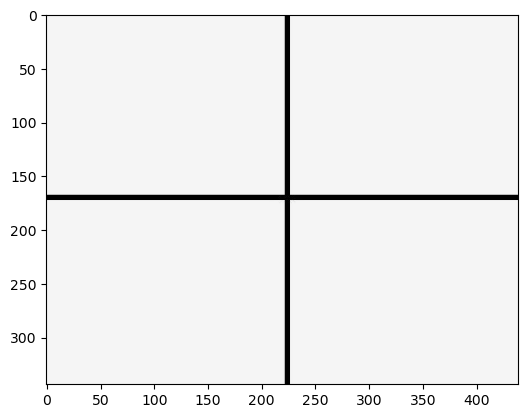

In [40]:
image_c = cv2.imread('horizontal_vertical.jpg')
plt.imshow(image_c)

In [41]:
image_g = cv2.cvtColor(image_c, cv2.COLOR_BGR2GRAY)
image_canny = cv2.Canny(image_g, 50, 200, apertureSize = 3)
image_canny

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

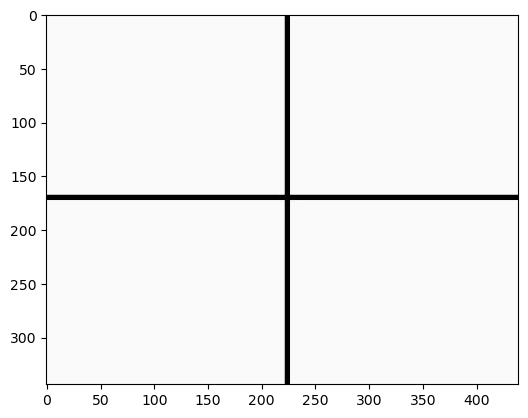

In [42]:
plt.imshow(image_g, cmap='gray')

In [43]:
# rho accuracy of 1 pixel and theta accuracy of np.pi / 180 (1 degree)
# threshold is number of points on line
# Try 300, 400 and 500
lines = cv2.HoughLines(image_canny, 1, np.pi/180, 300)

In [44]:
lines
# Note that 1.57 rad is 89.95437
# Note that rho was the distance from the origin

array([[[173.       ,   1.5707964]],

       [[167.       ,   1.5707964]],

       [[226.       ,   0.       ]],

       [[221.       ,   0.       ]]], dtype=float32)

In [45]:
if lines is not None:
    for i in range(0, len(lines)):
        # coordinate of the HOUGH space 
        rho = lines[i][0][0]
        theta = lines[i][0][1]
        
        # converting to normal coordinate space
        x0 = rho * np.cos(theta)
        y0 = rho * np.sin(theta)
        
        a = np.cos(theta)
        b = np.sin(theta)
        
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))

        cv2.line(image_c, (x1, y1), (x2, y2), (255, 0, 0), 2)
            
            
# cv2.imshow('Hough Lines', image_c)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

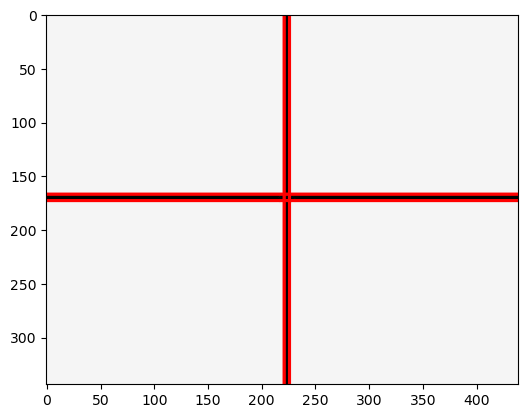

In [46]:
plt.imshow(image_c)

In [47]:
# DETECT LANE LINES ON IMAGE

import matplotlib.pyplot as plt
import numpy as np
import cv2
import matplotlib.image as mpimg

(540, 956, 3)

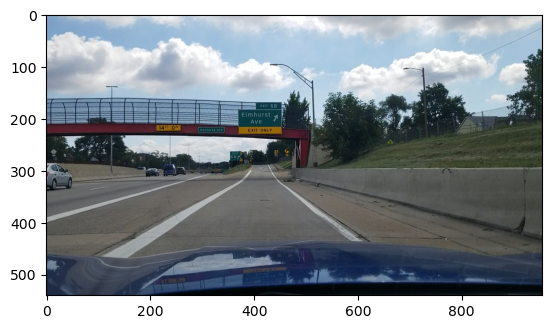

In [48]:
image_c = mpimg.imread('new_test_image_3.jpg')
plt.imshow(image_c)  
image_c.shape

(540, 956)

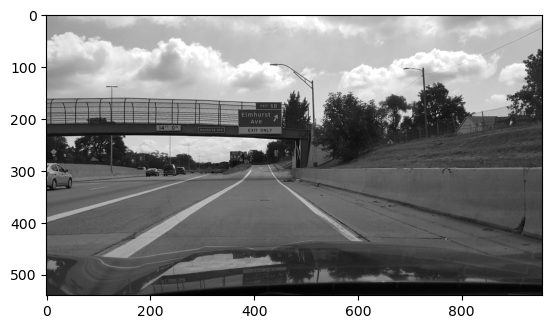

In [49]:
image_g = cv2.cvtColor(image_c, cv2.COLOR_RGB2GRAY)
plt.imshow(image_g, cmap = 'gray')  
image_g.shape

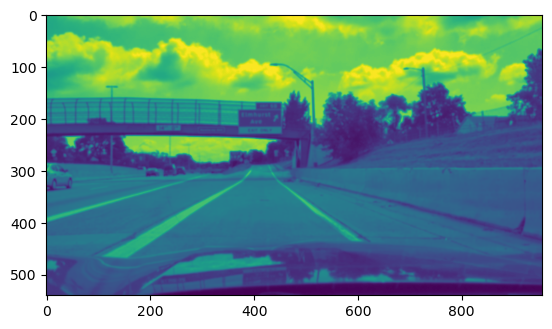

In [50]:
image_blurred = cv2.GaussianBlur(image_g, (7, 7), 0)
plt.imshow(image_blurred)  

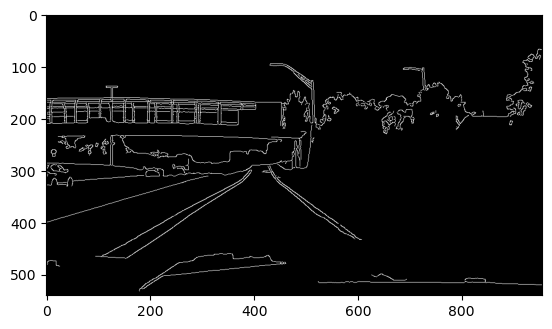

In [51]:
threshold_low = 10
threshold_high = 200

image_canny = cv2.Canny(image_blurred, threshold_low, threshold_high)
plt.imshow(image_canny, cmap = 'gray')  

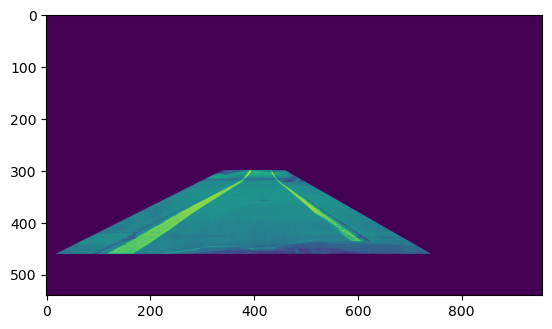

In [52]:
# Visualize the region of interest
vertices = np.array([[
    (20,460),
    (340, 300), 
    (460, 300), 
    (740,460)
]], dtype=np.int32)    

mask = np.zeros_like(image_g)   
cv2.fillPoly(mask, vertices, 255)
masked_image = cv2.bitwise_and(image_g, mask)

plt.figure()
plt.imshow(masked_image)

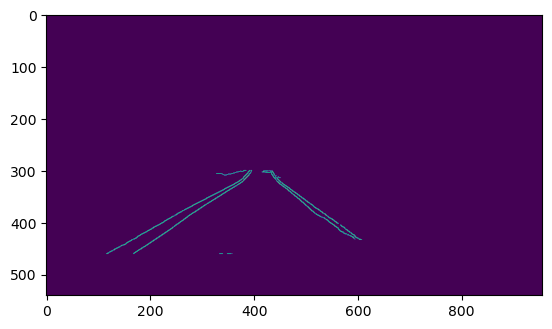

In [53]:
masked_image = cv2.bitwise_and(image_canny, mask)
plt.figure()
plt.imshow(masked_image)

In [54]:
# HOUGH LINES DETECTION AND DRAW FUNCTION ---------------- 

In [55]:
def detect_lines (image):
    Rres = 2 # size of the bin (Hough space) // distance resolution in pixels 
    Thetares = 1*np.pi/180 # angular resolution in radians 
    Threshold = 40 # minimum number of votes // minimum number of intersections in a bin (Hough space) to considered as a line 
    minLineLength = 100# output line length // minimum number of pixels making up a line
    maxLineGap = 50 # if smaller than this gap, 2 seperate lines will be connected as a line // maximum gap in pixels between connectable line segments

    lines = cv2.HoughLinesP(
        image,
        Rres,
        Thetares,
        Threshold,
        np.array([]),
        minLineLength,
        maxLineGap
    )

    return lines


detected_lines = detect_lines(masked_image)
detected_lines

array([[[120, 459, 263, 377]],

       [[168, 460, 389, 311]],

       [[419, 301, 607, 433]],

       [[255, 382, 382, 317]],

       [[118, 460, 226, 400]],

       [[116, 460, 311, 352]]], dtype=int32)

(540, 956, 3)


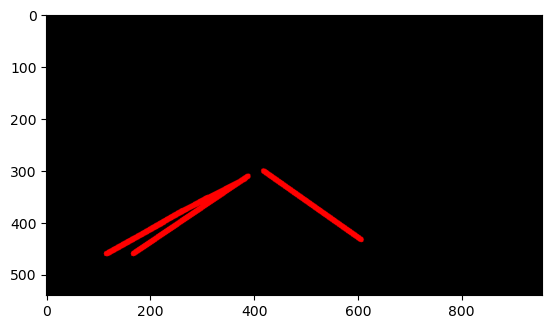

In [56]:
# draw the detected lines on a whole black image
def draw_lines_image(image, lines):
    # line_image = np.zeros_like(image) # empty black image

    # should use this method, use the 3 channel black image
    # because if use the above, there's only one channel --> gray scale channel 
    # and the color drawn on that image can be the same color as the gray scale channel
    # thius we might see there's no lines in the result 
    line_image = np.zeros((
        image.shape[0], 
        image.shape[1], 
        3
    ), dtype=np.uint8)

    print(line_image.shape)

    if lines is not None:
        for line in lines:
            # change 2 dimension to 1 dimension with 4 elements array
            # if it's already one dimension then it's fine
            x1, y1, x2, y2 = line.reshape(4) 
            start_point = (x1, y1)
            end_point = (x2, y2)
            color = (255, 0, 0)
            thickness = 10
            cv2.line(line_image, start_point, end_point, color, thickness)
    
    return line_image


lines_image = draw_lines_image(masked_image, detected_lines)

plt.figure()
plt.imshow(lines_image) 

In [57]:
# we see there are too many lines (each side left and right)
# we only want one line on each side
# so we're gonna average out many lines into one line (calculate average values)

def average_slope_intercept(image, lines):
    left_fit    = [] # left side
    right_fit   = [] # right side
    if lines is None:
        return None
    for line in lines:
        x1, y1, x2, y2 = line.reshape(4)

        # Numpy polyfit() is a method that fits the data within a polynomial function
        # from data points --> return a function that map those datas
        # in this case 1st degree function means x^1 --> or y = ax + b
        # --> return us [a, b]
        parameters = np.polyfit((x1,x2), (y1,y2), 1) 
        # slope = a, intercep = b
        slope = parameters[0]
        intercept = parameters[1]

        # slope < 0 --> left line else right line
        if slope < 0: # y is reversed in image
            left_fit.append((slope, intercept))
        else:
            right_fit.append((slope, intercept))
            
    # average all lines into one line on each side    
    left_fit_average  = np.average(left_fit, axis=0)
    right_fit_average = np.average(right_fit, axis=0)

    # make to a certain points, we want points to draw the new lines on screen
    left_line  = make_points(image, left_fit_average)
    right_line = make_points(image, right_fit_average)
    averaged_lines = [left_line, right_line]
    return averaged_lines


def make_points(image, line):
    slope, intercept = line
    y1 = int(image.shape[0]) # bottom of the image
    y2 = int(y1*3/5)         # slightly lower than the middle
    x1 = int((y1 - intercept)/slope) # x = (y - b) / a
    x2 = int((y2 - intercept)/slope)
    return np.array([x1, y1, x2, y2])

(540, 956, 3)


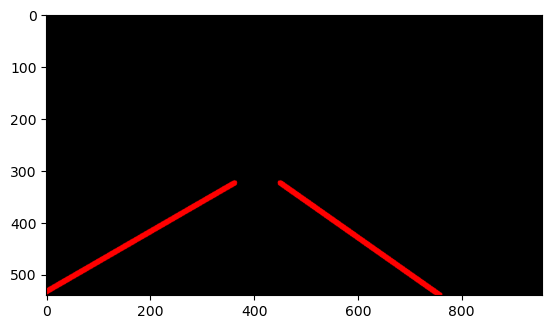

In [58]:
# after detecting all lines, average them
average_lines = average_slope_intercept(image_g, detected_lines)
average_lines_image = draw_lines_image(image_g, average_lines)
plt.imshow(average_lines_image);

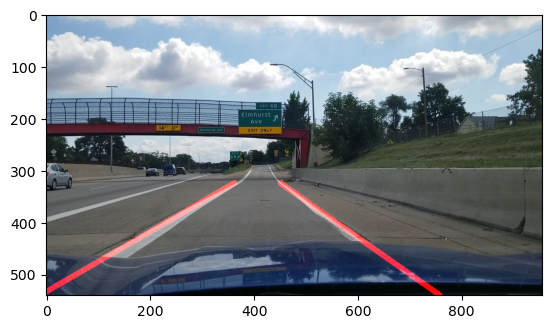

In [59]:
# draw the lines image above on the original image

α = 1
β = 1
γ = 0    

# Resultant weighted image is calculated as follows: original_img * α + img * β + γ
Image_with_lines = cv2.addWeighted(
    image_c, α, 
    average_lines_image, β, 
    γ
)

plt.imshow(Image_with_lines)